In [5]:
import sys
import importlib.util
import json
import numpy as np
import joblib
import matplotlib.pyplot as plt
from pathlib import Path

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT / "scripts"))

# ── Import simulator ──────────────────────────────────────────────────────────
spec = importlib.util.spec_from_file_location("simulator", ROOT / "scripts" / "simulator.py")
mod  = importlib.util.module_from_spec(spec)
spec.loader.exec_module(mod)
simulate_fast = mod.simulate_fast

obs_data = np.load(ROOT / "data" / "obs_data.npz")
obs_inf  = obs_data["obs_inf"]
obs_rew  = obs_data["obs_rew"]
obs_deg  = obs_data["obs_deg"]

data      = np.load(ROOT / "data" / "prior_simulations.npz")
thetas    = data["thetas"]
sim_inf   = data["infected_fractions"]
sim_rew   = data["rewire_counts"]
sim_deg   = data["degree_histograms"]


# ── Degree distribution helpers ───────────────────────────────────────────────
DEGREES = np.arange(31, dtype=float)

def _degree_mean(deg):   # (M, R, 31) → (M, 1)
    total = deg.sum(axis=2, keepdims=True).clip(min=1)
    return ((deg * DEGREES).sum(axis=2, keepdims=True) / total).mean(axis=1)

def _degree_std(deg):    # (M, R, 31) → (M, 1)
    total = deg.sum(axis=2, keepdims=True).clip(min=1)
    mu  = (deg * DEGREES).sum(axis=2) / total.squeeze(2)
    mu2 = (deg * DEGREES**2).sum(axis=2) / total.squeeze(2)
    return np.sqrt((mu2 - mu**2).clip(min=0)).mean(axis=1, keepdims=True)

def _degree_entropy(deg):  # (M, R, 31) → (M, 1)
    """Shannon entropy of the degree distribution — sensitive to distribution shape."""
    total = deg.sum(axis=2, keepdims=True).clip(min=1)
    p = deg / total
    return -(p * np.log(p + 1e-10)).sum(axis=2).mean(axis=1, keepdims=True)

def _degree_quantile(deg, q):  # (M, R, 31) → (M, 1)
    """q-th quantile of the degree distribution, averaged over replicates."""
    total = deg.sum(axis=2, keepdims=True).clip(min=1)
    cdf = np.cumsum(deg / total, axis=2)          # (M, R, 31)
    return (cdf < q).sum(axis=2).astype(float).mean(axis=1, keepdims=True)


# ── Active set for direct-distance rejection ABC ──────────────────────────────
ACTIVE_SET = "balanced"

print(f"Active set: '{ACTIVE_SET}' ({len(SUMMARY_SETS[ACTIVE_SET])} features)")
for s, feats in SUMMARY_SETS.items():
    print(f"  {s:15s}: {len(feats):2d} features")

# ── Feature catalogue (scalar summaries only) ─────────────────────────────────
# All features reduce (M, R, …) → (M, 1), keeping dimensionality equal across
# modalities so no single group dominates the Euclidean distance.

FEATURE_FUNCS = {
    # --- infection ---
    "peak_inf":          lambda i, w, d: np.max(i, axis=2).mean(axis=1, keepdims=True),
    "time_to_peak_inf":  lambda i, w, d: np.argmax(i, axis=2).astype(float).mean(axis=1, keepdims=True),
    "final_inf":         lambda i, w, d: i[:, :, -1].mean(axis=1, keepdims=True),
    "total_inf":         lambda i, w, d: i.sum(axis=2).mean(axis=1, keepdims=True),
    "epidemic_duration": lambda i, w, d: (i > 0.01).sum(axis=2).astype(float).mean(axis=1, keepdims=True),
    "std_peak_inf":      lambda i, w, d: np.max(i, axis=2).std(axis=1, keepdims=True),
    "std_total_inf":     lambda i, w, d: i.sum(axis=2).std(axis=1, keepdims=True),
    # --- rewiring ---
    "total_rew":         lambda i, w, d: w.sum(axis=2).mean(axis=1, keepdims=True),
    "peak_rew":          lambda i, w, d: np.max(w, axis=2).mean(axis=1, keepdims=True),
    "time_to_peak_rew":  lambda i, w, d: np.argmax(w, axis=2).astype(float).mean(axis=1, keepdims=True),
    "std_total_rew":     lambda i, w, d: w.sum(axis=2).std(axis=1, keepdims=True),
    "std_peak_rew":      lambda i, w, d: np.max(w, axis=2).std(axis=1, keepdims=True),
    # --- degree histogram ---
    "mean_degree":       lambda i, w, d: _degree_mean(d),
    "std_degree":        lambda i, w, d: _degree_std(d),
    "degree_entropy":    lambda i, w, d: _degree_entropy(d),
    "degree_q25":        lambda i, w, d: _degree_quantile(d, 0.25),
    "degree_q50":        lambda i, w, d: _degree_quantile(d, 0.50),
    "degree_q75":        lambda i, w, d: _degree_quantile(d, 0.75),
    "isolated_frac":     lambda i, w, d: (d[:, :, 0] / d.sum(axis=2).clip(min=1)).mean(axis=1, keepdims=True),
    "high_degree_frac":  lambda i, w, d: (d[:, :, 20:].sum(axis=2) / d.sum(axis=2).clip(min=1)).mean(axis=1, keepdims=True),
}

# ── Summary sets (direct-distance ABC) ────────────────────────────────────────
SUMMARY_SETS = {
    "infection_only": [
        "peak_inf", "time_to_peak_inf", "final_inf", "total_inf",
    ],
    "rewiring_only": [
        "total_rew", "peak_rew", "time_to_peak_rew",
    ],
    "degree_only": [
        "mean_degree", "std_degree", "isolated_frac", "high_degree_frac",
    ],
    # "balanced": equal features per modality + informative additions.
    # epidemic_duration separates β from ρ (ρ can suppress without shortening
    # the epidemic). Cross-replicate rewiring variance is especially sensitive
    # to ρ. Degree entropy + quartiles capture distribution shape beyond mean/std.
    "balanced": [
        # infection — 5 scalars
        "peak_inf", "epidemic_duration", "total_inf", "std_peak_inf", "std_total_inf",
        # rewiring — 4 scalars (mean + variance)
        "total_rew", "peak_rew", "std_total_rew", "std_peak_rew",
        # degree — 6 scalars (shape + spread + tails)
        "mean_degree", "std_degree", "degree_entropy",
        "degree_q25", "degree_q50", "degree_q75",
    ],
}

def compute_summaries(inf, rew, deg, feature_set=ACTIVE_SET):
    """Compute summary statistics for a batch or single observation.

    Parameters
    ----------
    inf : (M, R, T+1) or (R, T+1)
    rew : (M, R, T+1) or (R, T+1)
    deg : (M, R, 31)  or (R, 31)

    Returns
    -------
    (M, n_features) or (n_features,) for a single observation
    """
    squeeze = inf.ndim == 2
    if squeeze:
        inf, rew, deg = inf[np.newaxis], rew[np.newaxis], deg[np.newaxis]
    rew = rew.astype(float)
    deg = deg.astype(float)

    parts = []
    for name in SUMMARY_SETS[feature_set]:
        feat = FEATURE_FUNCS[name](inf, rew, deg)   # (M,) or (M, k)
        if feat.ndim == 1:
            feat = feat[:, np.newaxis]
        parts.append(feat)

    result = np.concatenate(parts, axis=1)           # (M, n_features)
    return result[0] if squeeze else result

# ── Load observed data ────────────────────────────────────────────────────────
obs_data = np.load(ROOT / "data" / "obs_data.npz")
obs_inf  = obs_data["obs_inf"]
obs_rew  = obs_data["obs_rew"]
obs_deg  = obs_data["obs_deg"]

sim_stats = compute_summaries(sim_inf, sim_rew, sim_deg)    # (M, n_features)
obs_stats = compute_summaries(obs_inf, obs_rew, obs_deg)    # (n_features,)

# ── Load SMC inputs ───────────────────────────────────────────────────────────
smc_in              = np.load(ROOT / "data" / "smc_inputs.npz")
thetas              = smc_in["thetas"]
epsilon             = float(smc_in["epsilon"])
feat_std            = smc_in["feat_std"]
distances           = smc_in["distances"]
obs_stats_balanced  = smc_in["obs_stats_balanced"]
sim_stats_balanced  = smc_in["sim_stats_balanced"]
obs_stats_projected = smc_in["obs_stats_projected"]
proj_std            = smc_in["proj_std"]
epsilon_semiauto    = float(smc_in["epsilon_semiauto"])
proj_distances      = smc_in["proj_distances"]
lasso_idx           = smc_in["lasso_idx"]

obs_stats_lasso     = obs_stats_balanced[lasso_idx]
feat_std_lasso      = feat_std[lasso_idx]

# ── Load proposal SDs ─────────────────────────────────────────────────────────
prop = np.load(ROOT / "data" / "smc_proposal.npz")
PROPOSAL_SD_balanced  = prop["PROPOSAL_SD_balanced"]
PROPOSAL_SD_lasso     = prop["PROPOSAL_SD_lasso"]
PROPOSAL_SD_semiauto  = prop["PROPOSAL_SD_semiauto"]

# ── Load ridge model ──────────────────────────────────────────────────────────
reg = joblib.load(ROOT / "scripts" / "ridge.pkl")

print("All inputs loaded.")
print(f"ε balanced  = {epsilon:.4f}")
print(f"ε semi-auto = {epsilon_semiauto:.4f}")
print(f"Particles available: {(distances <= epsilon).sum()}")

Active set: 'balanced' (15 features)
  infection_only :  4 features
  rewiring_only  :  3 features
  degree_only    :  4 features
  balanced       : 15 features
All inputs loaded.
ε balanced  = 1.2852
ε semi-auto = 0.3687
Particles available: 100


In [12]:
# ── Config ────────────────────────────────────────────────────────────────────
PRIOR_LOW    = np.array([0.05, 0.02, 0.0])
PRIOR_HIGH   = np.array([0.50, 0.20, 0.8])
N_PARTICLES  = 100
N_GENS       = 10
ALPHA        = 0.75    # next ε = α-quantile of current particle distances
R            = 40
SEED         = 42

rng = np.random.default_rng(SEED)

def in_prior(theta):
    return np.all(theta >= PRIOR_LOW) and np.all(theta <= PRIOR_HIGH)

# ── get_stats functions ───────────────────────────────────────────────────────
def get_stats_balanced(theta, rng):
    results = [simulate_fast(*theta, rng=rng) for _ in range(R)]
    inf = np.array([r[0] for r in results])[np.newaxis]
    rew = np.array([r[1] for r in results])[np.newaxis]
    deg = np.array([r[2] for r in results])[np.newaxis]
    return compute_summaries(inf, rew, deg, feature_set="balanced")[0]

def get_stats_lasso(theta, rng):
    return get_stats_balanced(theta, rng)[lasso_idx]

def get_stats_semiauto(theta, rng):
    raw = get_stats_balanced(theta, rng)
    return reg.predict(raw.reshape(1, -1))[0]

def distance_balanced(s):
    return np.linalg.norm((s - obs_stats_balanced) / feat_std)

def distance_lasso(s):
    return np.linalg.norm((s - obs_stats_lasso) / feat_std_lasso)

def distance_semiauto(s):
    return np.linalg.norm((s - obs_stats_projected) / proj_std)

In [21]:
# ── SMC-ABC runner ────────────────────────────────────────────────────────────
def run_smc(get_stats_fn, distance_fn, prior_dists, eps_init,
            proposal_sd, label):

    print(f"\n{'='*50}")
    print(f"SMC-ABC: {label}")
    print(f"{'='*50}")

    # ── Generation 0: initialise from prior draws ─────────────────────────────
    accepted_idx = np.where(prior_dists <= eps_init)[0]
    chosen       = rng.choice(accepted_idx, size=N_PARTICLES, replace=False)
    particles    = thetas[chosen].copy()
    weights      = np.ones(N_PARTICLES) / N_PARTICLES
    eps          = eps_init

    all_particles = [particles.copy()]
    all_eps       = [eps]

    for gen in range(1, N_GENS + 1):
        # ── Resample ──────────────────────────────────────────────────────────
        indices   = rng.choice(N_PARTICLES, size=N_PARTICLES, p=weights)
        particles = particles[indices]

        # ── Perturb & reweight ─────────────────────────────────────────────────
        new_particles  = np.empty_like(particles)
        new_dists      = np.empty(N_PARTICLES)
        accepted       = 0
        total_attempts = 0

        for i in range(N_PARTICLES):
            if i % 50 == 0:
                print(f"    Particle {i:4d}/{N_PARTICLES}  accepted so far: {accepted}", end="\r")
            attempts = 0
            while True:
                attempts += 1
                proposal = particles[i] + rng.normal(0, proposal_sd)
                if not in_prior(proposal):
                    continue
                d = distance_fn(get_stats_fn(proposal, rng))
                if d < eps:
                    new_particles[i] = proposal
                    new_dists[i]     = d
                    accepted        += 1
                    break
            total_attempts += attempts

        print(f"    Particle {N_PARTICLES}/{N_PARTICLES}  accepted: {accepted}        ")

        particles = new_particles
        weights   = np.ones(N_PARTICLES) / N_PARTICLES

        # ── Adapt ε for next generation ────────────────────────────────────────
        eps = np.quantile(new_dists, ALPHA)

        all_particles.append(particles.copy())
        all_eps.append(eps)

        print(f"  Gen {gen:2d}  ε={eps:.4f}  "
              f"efficiency={N_PARTICLES/total_attempts:.1%}  "
              f"β={particles[:,0].mean():.3f}  "
              f"γ={particles[:,1].mean():.3f}  "
              f"ρ={particles[:,2].mean():.3f}")

        if N_PARTICLES / total_attempts < 0.01:
            print("  Efficiency too low — stopping early.")
            break

    return np.array(all_particles), np.array(all_eps)

In [25]:
# ── Run all three variants ────────────────────────────────────────────────────
smc_balanced,  eps_balanced  = run_smc(
    get_stats_balanced,  distance_balanced,
    distances,     epsilon,
    PROPOSAL_SD_balanced,  "Balanced")

smc_lasso,     eps_lasso     = run_smc(
    get_stats_lasso,     distance_lasso,
    distances,     epsilon,
    PROPOSAL_SD_lasso,     "LASSO")

smc_semiauto,  eps_semiauto  = run_smc(
    get_stats_semiauto,  distance_semiauto,
    proj_distances, epsilon_semiauto,
    PROPOSAL_SD_semiauto,  "Semi-auto")


SMC-ABC: Balanced
    Particle 100/100  accepted: 100        
  Gen  1  ε=1.2260  efficiency=9.7%  β=0.200  γ=0.095  ρ=0.332
    Particle 100/100  accepted: 100        
  Gen  2  ε=1.1672  efficiency=8.1%  β=0.201  γ=0.092  ρ=0.333
    Particle 100/100  accepted: 100        
  Gen  3  ε=1.1016  efficiency=7.6%  β=0.204  γ=0.090  ρ=0.331
    Particle 100/100  accepted: 100        
  Gen  4  ε=1.0578  efficiency=4.9%  β=0.205  γ=0.093  ρ=0.336
    Particle 100/100  accepted: 100        
  Gen  5  ε=1.0088  efficiency=5.0%  β=0.193  γ=0.091  ρ=0.325
    Particle 100/100  accepted: 100        
  Gen  6  ε=0.9409  efficiency=4.7%  β=0.193  γ=0.090  ρ=0.328
    Particle 100/100  accepted: 100        
  Gen  7  ε=0.8790  efficiency=3.5%  β=0.185  γ=0.088  ρ=0.320
    Particle 100/100  accepted: 100        
  Gen  8  ε=0.8385  efficiency=2.6%  β=0.182  γ=0.086  ρ=0.326
    Particle 100/100  accepted: 100        
  Gen  9  ε=0.8025  efficiency=2.2%  β=0.183  γ=0.088  ρ=0.325
    Particle 100/1

In [26]:
# ── Final posterior comparison ────────────────────────────────────────────────
labels    = ["β", "γ", "ρ"]
prior_std = (PRIOR_HIGH - PRIOR_LOW) / np.sqrt(12)
smc_results = {
    "balanced":  smc_balanced[-1],
    "LASSO":     smc_lasso[-1],
    "semi-auto": smc_semiauto[-1],
}

print(f"\n{'':12s} {'β':>8} {'γ':>8} {'ρ':>8}")
print(f"{'prior std':12s} {prior_std[0]:>8.4f} {prior_std[1]:>8.4f} {prior_std[2]:>8.4f}")
for name, particles in smc_results.items():
    stds = particles.std(axis=0)
    rel  = stds / prior_std
    print(f"{name:12s} {stds[0]:>8.4f} {stds[1]:>8.4f} {stds[2]:>8.4f}  "
          f"(rel: {rel[0]:.2f} {rel[1]:.2f} {rel[2]:.2f})")


                    β        γ        ρ
prior std      0.1299   0.0520   0.2309
balanced       0.0310   0.0099   0.0339  (rel: 0.24 0.19 0.15)
LASSO          0.0314   0.0104   0.0331  (rel: 0.24 0.20 0.14)
semi-auto      0.0095   0.0116   0.0222  (rel: 0.07 0.22 0.10)


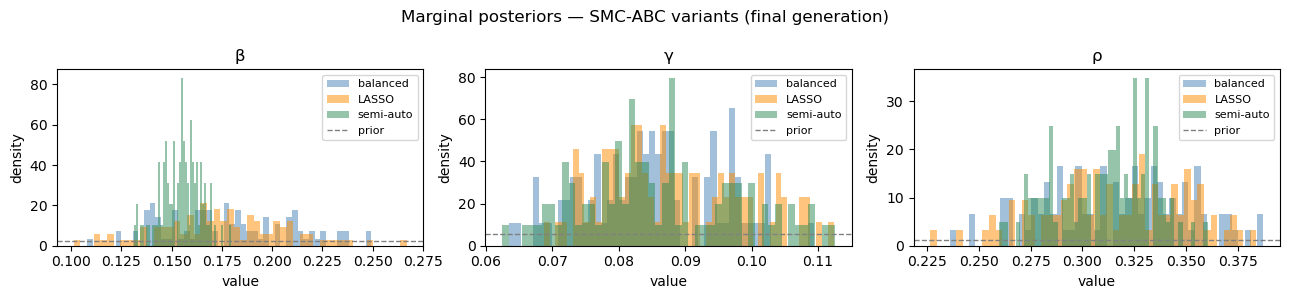

In [27]:
# ── Marginal posteriors ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 3))
colors = {"balanced": "steelblue", "LASSO": "darkorange", "semi-auto": "seagreen"}
for col, param in enumerate(labels):
    for name, particles in smc_results.items():
        axes[col].hist(particles[:, col], bins=50, density=True,
                       alpha=0.5, color=colors[name], label=name)
    axes[col].axhline(1 / (PRIOR_HIGH[col] - PRIOR_LOW[col]),
                      color="grey", ls="--", lw=1, label="prior")
    axes[col].set(title=param, xlabel="value", ylabel="density")
    axes[col].legend(fontsize=8)
plt.suptitle("Marginal posteriors — SMC-ABC variants (final generation)")
plt.tight_layout()
plt.savefig(ROOT / "figures" / "smc_posteriors.png", dpi=150, bbox_inches="tight")
plt.show()

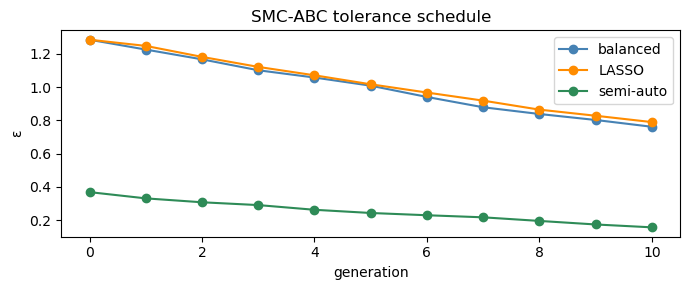

In [28]:
# ── ε schedule ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 3))
for name, eps_hist in [("balanced", eps_balanced),
                        ("LASSO",    eps_lasso),
                        ("semi-auto", eps_semiauto)]:
    ax.plot(eps_hist, marker="o", label=name, color=colors[name])
ax.set(xlabel="generation", ylabel="ε", title="SMC-ABC tolerance schedule")
ax.legend()
plt.tight_layout()
plt.savefig(ROOT / "figures" / "smc_epsilon_schedule.png", dpi=150, bbox_inches="tight")
plt.show()